## Análisis inmuebles Zaragoza

### Importación de librerías


In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Visión general

In [170]:
df = pd.read_csv("inmuebles_zaragoza_limpio.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Titulo        150 non-null    str  
 1   Precio        150 non-null    int64
 2   Habitaciones  150 non-null    int64
 3   Metros        150 non-null    int64
 4   Planta        5 non-null      str  
 5   Barrio        150 non-null    str  
 6   Fuente        150 non-null    str  
dtypes: int64(3), str(4)
memory usage: 8.3 KB


In [171]:
df.head()

,Titulo,Precio,Habitaciones,Metros,Planta,Barrio,Fuente
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,NaN,"Paseo de Fernando el Católico, Universidad San...",pag1.html
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,NaN,"Calle de Mariano Barbasán, Universidad San Fra...",pag1.html
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,NaN,"Camino de las Torres, Parque Miraflores, Zaragoza",pag1.html
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,NaN,"Via Univérsitas, Pol Universidad Romareda, Zar...",pag1.html
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,NaN,"Calle de los Lagos de Coronas, Miralbueno, Zar...",pag1.html


Podemos ver un dataset completo, pero con columnas que no nos aportan información (o muy vacías) y por otro lado falta información relevante. Asi pues, vamos a proceder a la limpieza de los datos y a la creación de nuevas columnas a partir de las ya existentes. 

### Limpieza de datos

La columna "Planta" está prácticamente vacía y la columna "fuente" no nos aporta información relevante, asi que las elimnaremos de nuestro dataset: 

In [172]:
# Eliminación de columnas
df.drop(columns=['Planta', 'Fuente'], inplace=True)

# Comprobación
df.head()

,Titulo,Precio,Habitaciones,Metros,Barrio
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,"Paseo de Fernando el Católico, Universidad San..."
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,"Calle de Mariano Barbasán, Universidad San Fra..."
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,"Camino de las Torres, Parque Miraflores, Zaragoza"
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,"Via Univérsitas, Pol Universidad Romareda, Zar..."
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,"Calle de los Lagos de Coronas, Miralbueno, Zar..."


A continuación vamos a proceder a la limpieza de la columna Barrio. Como vemos, hay mucha información en esa columna, asi que desarrollaremos una función que nos permita quedarnos solo con el nombre del barrio, almacenando los valore en una nueva columna. 

In [173]:
# 1. LIMPIEZA DE BARRIO
def limpiar_barrio(texto):
    # Separa por comas y coge el penúltimo elemento (donde suele estar el barrio)
    partes = texto.split(',')
    if len(partes) > 1:
        candidato = partes[-2].strip()
        # Si sale un número (ej. "Calle, 32"), cogemos el anterior
        if candidato[0].isdigit(): 
            return partes[-3].strip()
        return candidato
    return "Zaragoza Centro"

df['Barrio_Oficial'] = df['Barrio'].apply(limpiar_barrio)

# 2. LIMPIEZA DE NOMBRE DE BARRIO
def limpiar_nombre_barrio(texto):
    if isinstance(texto, str):
        return texto.split('-')[0].strip() # dividios y nos quedamos con el primero
    return texto

# Aplicamos la limpieza
df['Barrio_Oficial'] = df['Barrio_Oficial'].apply(limpiar_nombre_barrio)

#Eliminación del a columna antigua
df.drop(columns=['Barrio'], inplace=True)

df.head()

,Titulo,Precio,Habitaciones,Metros,Barrio_Oficial
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,Universidad San Francisco
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,Universidad San Francisco
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,Parque Miraflores
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,Pol Universidad Romareda
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,Miralbueno


### Análisis de la columna 'Precio'

Dado que el precio es nuestra columna target vamos a inspeccionarla para saber como se distribuye. 

In [174]:
df['Precio'].describe()

count       150.000000
mean     316846.586667
std      180893.943450
min       65000.000000
25%      176225.000000
50%      276500.000000
75%      399750.000000
max      895000.000000
Name: Precio, dtype: float64

Vemos que parecer ser que hay valores bastante alejados entre si (alta desviación estándar y rango). Para ver mejor si luego podemos usar la media como estádistico base, la comparemos con la mediana y a la vez observaremos la distribución de los valores a través de un histograma: 

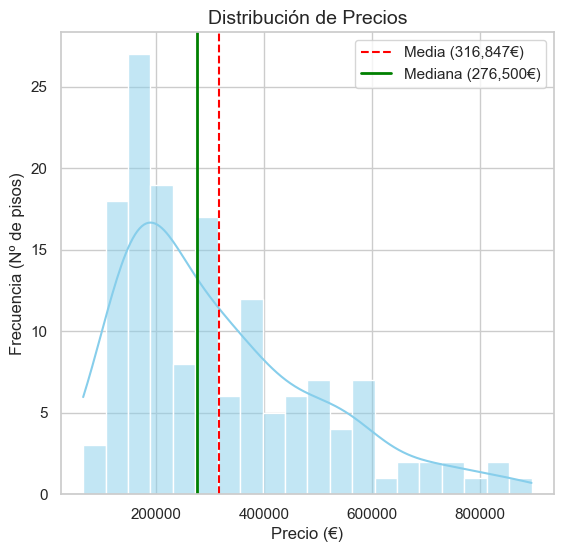

In [175]:
# Configuración estética
sns.set(style="whitegrid") 
plt.figure(figsize=(14, 6)) 

# HISTOGRAMA
plt.subplot(1, 2, 1) 
sns.histplot(data=df, x='Precio', kde=True, color='skyblue', bins=20)
plt.title('Distribución de Precios', fontsize=14)
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia (Nº de pisos)')

# Añadimos líneas verticales para Media y Mediana (Lo que queremos comparar)
plt.axvline(df['Precio'].mean(), color='red', linestyle='--', label=f'Media ({df["Precio"].mean():,.0f}€)')
plt.axvline(df['Precio'].median(), color='green', linewidth=2, label=f'Mediana ({df["Precio"].median():,.0f}€)')
plt.legend()



Observamos: 
* Una clara asimetría hacia la derecha (cola) lo que indica posibles outliers en precios altos. 
* Una diferencia clara entre los valores de media y mediana (derivado de este fenómeno)

Visualizamos la aparición de outliers en otro tipo de gráfico: 

✅ Gráfico guardado como 'analisis_precios.png'


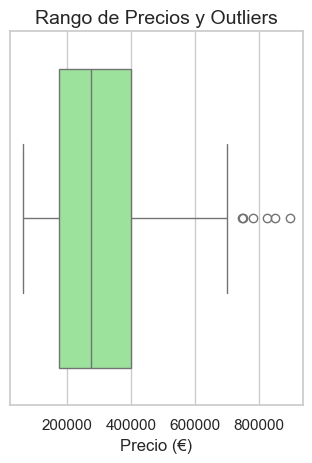

In [176]:
# --- GRÁFICO 2: BOXPLOT ---
plt.subplot(1, 2, 2) # (1 fila, 2 columnas, gráfico nº 2)
sns.boxplot(x=df['Precio'], color='lightgreen')
plt.title('Rango de Precios y Outliers', fontsize=14)
plt.xlabel('Precio (€)')

# Ajustar diseño y guardar
plt.tight_layout()
plt.savefig('analisis_precios.png')
print("✅ Gráfico guardado como 'analisis_precios.png'")
plt.show()

Confirmamos la presencia de outliers en los precios altos. Dado que eliminarlos sería un error (igual nos interesan esas mansiones y son de las que más provecho se puede sacar) vamos simplemente a cateogorizarlos: 

In [177]:
# Función para gestionar outliers 
def gestionar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    
    # Etiquetar
    df['Es_Outlier'] = np.where((df[columna] < limite_inferior) | (df[columna] > limite_superior), True, False)
    
    return df

# Aplicar en la columna precio
df = gestionar_outliers(df, 'Precio')

# Comprobar
df.head()

,Titulo,Precio,Habitaciones,Metros,Barrio_Oficial,Es_Outlier
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,Universidad San Francisco,False
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,Universidad San Francisco,False
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,Parque Miraflores,False
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,Pol Universidad Romareda,False
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,Miralbueno,False


### Creación de nuevas métricas

Vamos, a partir de las columnas que tenemos, crear nuevas métricas que permitan aportar información relevante a nuestro análisis. 

#### Precio por m2

Nos va a servir para comparar inmuebles entre sí. Calcularemos la métrica y luego la analizaremos para comprobar su distribución y la presencia de outliers. 

In [178]:
# Calculo de la métrica
df['Precio_m2'] = df['Precio'] / df['Metros']

df['Precio_m2'].head()

0    3117.647059
1    2549.549550
2    2137.096774
3    3359.550562
4    3363.636364
Name: Precio_m2, dtype: float64

In [179]:
df['Precio_m2'].describe()

count     150.000000
mean     2454.932437
std       711.818610
min         1.000000
25%      2000.000000
50%      2521.367521
75%      3024.691358
max      4054.054054
Name: Precio_m2, dtype: float64

A continuación, observamos su distribución, diferencia entre media y mediana, etc.

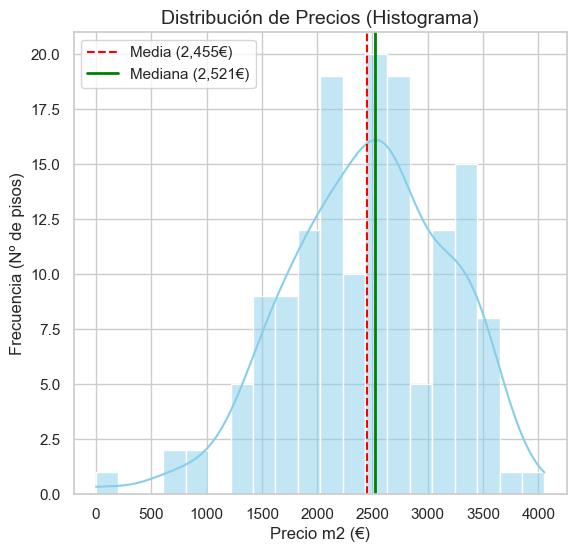

In [180]:
# Configuración estética
sns.set(style="whitegrid") # Fondo limpio
plt.figure(figsize=(14, 6)) # Tamaño de la imagen

# --- GRÁFICO 1: HISTOGRAMA ---
plt.subplot(1, 2, 1) # (1 fila, 2 columnas, gráfico nº 1)
sns.histplot(data=df, x='Precio_m2', kde=True, color='skyblue', bins=20)
plt.title('Distribución de Precios (Histograma)', fontsize=14)
plt.xlabel('Precio m2 (€)')
plt.ylabel('Frecuencia (Nº de pisos)')

# Añadimos líneas verticales para Media y Mediana (Clave para explicar la asimetría)
plt.axvline(df['Precio_m2'].mean(), color='red', linestyle='--', label=f'Media ({df["Precio_m2"].mean():,.0f}€)')
plt.axvline(df['Precio_m2'].median(), color='green', linewidth=2, label=f'Mediana ({df["Precio_m2"].median():,.0f}€)')
plt.legend()

Para el valor de 'Precio_m2' vemos una distribución mucho más parecida a la normal, con menor diferencia entre media y mediana y por tanto una distribución de valores más uniforme. Aun así, vamos la presencia de valores alejados que debemos investigar. 

En el .describe() hemos visto un valor mínimo de 1$ el m_2. Vamos a comprobar si es un error o si por el contrario es un inmueble de muy bajo precio o de muy alta extensión. 

In [181]:
df.loc[df['Precio_m2'] < 500, ['Titulo']]



,Titulo
119,Casa o chalet independiente en Puente Clavería...


Tras buscarlo en idealista, es un error (ponía que tenía 375.000 m2 de extensión) asi que procedemos a su eliminación. 

In [182]:
df.drop(119, inplace=True)

✅ Gráfico guardado como 'analisis_precios.png'


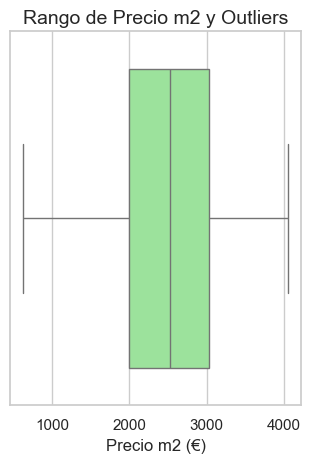

In [183]:
# --- GRÁFICO 2: BOXPLOT ---
plt.subplot(1, 2, 2) # (1 fila, 2 columnas, gráfico nº 2)
sns.boxplot(x=df['Precio_m2'], color='lightgreen')
plt.title('Rango de Precio m2 y Outliers', fontsize=14)
plt.xlabel('Precio m2 (€)')

# Ajustar diseño y guardar
plt.tight_layout()
plt.savefig('analisis_precios.png')
print("✅ Gráfico guardado como 'analisis_precios.png'")
plt.show()

De este modo ya podemos verel rango de los valores sin la presencia de outliers. 

#### Segmentación por tamaño

Vamos a construir 3 categorías según el tamaño que presenta el inmueble: 

In [184]:
# 1. TIPO DE VIVIENDA (Casa vs Piso)
# Si contiene "chalet", "casa" o "torre" es Unifamiliar. Si no, asumimos Piso.
def detectar_tipo(titulo):
    titulo = titulo.lower()
    if any(x in titulo for x in ["chalet", "casa", "unifamiliar"]):
        return "Casa/Chalet"
    elif "ático" in titulo or "atico" in titulo:
        return "Ático" # Los áticos son una categoría premium
    elif "duplex" in titulo or "dúplex" in titulo:
        return "Dúplex"
    else:
        return "Piso"

df['Tipo_Vivienda'] = df['Titulo'].apply(detectar_tipo)

df.head(20)

,Titulo,Precio,Habitaciones,Metros,Barrio_Oficial,Es_Outlier,Precio_m2,Tipo_Vivienda
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,Universidad San Francisco,False,3117.647059,Piso
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,Universidad San Francisco,False,2549.549550,Piso
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,Parque Miraflores,False,2137.096774,Piso
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,Pol Universidad Romareda,False,3359.550562,Piso
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,Miralbueno,False,3363.636364,Piso
5,Casa o chalet independiente en Calle de la Vía...,348000,2,220,Valdefierro,False,1581.818182,Casa/Chalet
6,"Piso en Calle de la Fabla Aragonesa, La Jota, ...",182000,2,72,La Jota,False,2527.777778,Piso
7,"Piso en Calle de Juan Bautista del Mazo, Almoz...",165000,2,63,Almozara,False,2619.047619,Piso
8,"Piso en Gran Vía Santiago Ramón y Cajal, Paseo...",575000,6,202,Paseo Sagasta,False,2846.534653,Piso
9,"Piso en Calle de Manuel Lasala, Universidad Sa...",700000,4,206,Universidad San Francisco,False,3398.058252,Piso


### Categoría de "Infravalorado"

Vamos a calcular la mediana (para no estar afectado por los outliers) para cada barrio y luego miraremos el precio de cada piso. Si su precio es un 10% menor de la mediana de su barrio, lo categorizaremos como 'Infravalorado'.

In [185]:
# Detección
# Calculamos la mediana de precio m2 por cada barrio
media_barrio = df.groupby('Barrio_Oficial')['Precio_m2'].transform('median')

#Etiquetar
df['Infravalorado'] = df['Precio_m2'] < (media_barrio * 0.90)

df.head()

,Titulo,Precio,Habitaciones,Metros,Barrio_Oficial,Es_Outlier,Precio_m2,Tipo_Vivienda,Infravalorado
0,"Piso en Paseo de Fernando el Católico, Univers...",265000,3,85,Universidad San Francisco,False,3117.647059,Piso,False
1,"Piso en Calle de Mariano Barbasán, Universidad...",283000,5,111,Universidad San Francisco,False,2549.549550,Piso,True
2,"Piso en Camino de las Torres, Parque Miraflore...",530000,6,248,Parque Miraflores,False,2137.096774,Piso,False
3,"Piso en Via Univérsitas, Pol Universidad Romar...",299000,3,89,Pol Universidad Romareda,False,3359.550562,Piso,False
4,"Piso en Calle de los Lagos de Coronas, Miralbu...",370000,3,110,Miralbueno,False,3363.636364,Piso,False


### Obtener dataset final

In [187]:
df.to_csv('inmuebles_zgz_final.csv')

media = df